In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Snapchat-1429388362.jpg', 'IMG_20220322_142117_384.jpg', 'IMG_20220322_141947_872.jpg', 'IMG_20220225_150250_575.jpg', 'IMG_20220225_150248_041.jpg', 'IMG_20220225_150246_134.jpg', 'IMG_20220225_150243_901.jpg', 'IMG_20220102_210029_060.jpg', 'IMG_20211218_114122_132.jpg', 'IMG_20220322_142120_048.jpg', '208acc8c-1e2a-4238-8361-b4198da3a397.mp4', 'a8e4b022-64cb-4e36-9fc8-0374585235e4.mp4', '6374ff8d-04ab-49fb-8d69-db1ae2897525.jpg', 'IMG_1862.PNG', '968f8636-c90e-44c2-b5e6-6f027457a7f4.jpg', '6d8f8afa-4c08-4bd3-b39d-feb71816ec38.jpg', '9012aed0-5bba-4574-9856-68800c88bde9.jpg', '8d7dd70a-f569-4a62-8134-4321f1622b7c.jpg', '582184a6-b426-427c-8edf-d1b9150b5218.jpg', '21fbb7fe-0acf-462c-9136-6a25154e113f.jpg', '666a2d4a-48db-4324-b13b-a16cd26e951c.jpg', '288073dd-c1b2-4c47-977c-3866e6690a59.mp4', '8450b92b-a3b8-4579-ae27-e3edc55a2ed6.mp4', '0f7e3e35-99be-4f57-8589-41a87f34cb04.mp4', '86092cef-116d-4227-ac5e-ca214714b4fc.mp4', 'e65ee5e6-9f04-4c4f-8fd7-2d7eab20001c.mp4', '9a7ea962-cb6d-49

In [3]:
import zipfile
zip_path = "/content/drive/MyDrive/Mammo-Bench/Preprocessed_Dataset.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully")

Unzipped successfully


In [4]:
import pandas as pd
DATA_ROOT = "/content"
CSV_PATH = "/content/drive/MyDrive/Mammo-Bench/BIRADS.csv"

df = pd.read_csv(CSV_PATH)

sample_path = df.iloc[0]["preprocessed_image_path"]
full_path = os.path.join(DATA_ROOT, sample_path)

print(full_path)
print(os.path.exists(full_path))

/content/Preprocessed_Dataset/inbreast/inbreast_0.jpg
True


In [5]:
print(df["BIRADS"].value_counts())

BIRADS
1.0    2553
3.0     455
2.0     405
4.0     358
5.0     313
6.0      12
0.0       1
Name: count, dtype: int64


In [6]:
df= df[(df['BIRADS']!=6) & (df['BIRADS']!=0)]
print(df["BIRADS"].value_counts())

BIRADS
1.0    2553
3.0     455
2.0     405
4.0     358
5.0     313
Name: count, dtype: int64


In [7]:
birads_map =  {
    1 : 0,
    2 : 1,
    3 : 2,
    4 : 3,
    5 : 4
}
revers_map = {
    0 : 1,
    1 : 2,
    2 : 3,
    3 : 4,
    4 : 5
}

df["birads_label"] = df["BIRADS"].map(birads_map)
print( df["birads_label"].head())

0    0
1    2
2    0
3    2
4    4
Name: birads_label, dtype: int64


In [8]:
print(df["BIRADS"].unique())
print(df["birads_label"].unique())
print(df["birads_label"].isna().sum())
print(df["birads_label"].dtype)

[1. 3. 5. 2. 4.]
[0 2 4 1 3]
0
int64


In [9]:
df["full_image_path"] = df["preprocessed_image_path"].apply(
    lambda x: os.path.join(DATA_ROOT, x)
)
print(df['full_image_path'].iloc[0])

missing = df[~df["full_image_path"].apply(os.path.exists)]
print("Missing files:", len(missing))

columns_needed = [
    "full_image_path",
    'source_subjectID',
    "BIRADS",
    "birads_label"

]

df = df[columns_needed].copy()

print(df.head())
print(df.shape)
print(df.columns)

/content/Preprocessed_Dataset/inbreast/inbreast_0.jpg
Missing files: 0
                                     full_image_path source_subjectID  BIRADS  \
0  /content/Preprocessed_Dataset/inbreast/inbreas...         22678622     1.0   
1  /content/Preprocessed_Dataset/inbreast/inbreas...         22678646     3.0   
2  /content/Preprocessed_Dataset/inbreast/inbreas...         22678670     1.0   
3  /content/Preprocessed_Dataset/inbreast/inbreas...         22678694     3.0   
4  /content/Preprocessed_Dataset/inbreast/inbreas...         22614074     5.0   

   birads_label  
0             0  
1             2  
2             0  
3             2  
4             4  
(4084, 4)
Index(['full_image_path', 'source_subjectID', 'BIRADS', 'birads_label'], dtype='object')


In [10]:
from torch.utils.data import Dataset
from PIL import Image

class MammoBenchDataset (Dataset):
  def __init__(self,dataframe,transform=None):
    self.dataframe = dataframe.reset_index(drop=True)
    self.transform = transform

  def __len__(self):
    return (len(self.dataframe))

  def __getitem__ (self,idx):
    row = self.dataframe.iloc[idx]

    image_path = row['full_image_path']
    birads_label = row['birads_label']

    image = Image.open(image_path).convert("RGB")

    if self.transform:
      image = self.transform(image)

    return image, birads_label


dataset = MammoBenchDataset(df)
print(f'Length of the dataset : {len(dataset)}')
img,label = dataset[124]
print(f"Image type: {type(img)}")
print(f"Image Label: {label}")

Length of the dataset : 4084
Image type: <class 'PIL.Image.Image'>
Image Label: 0


In [11]:
from torchvision import transforms


train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225]
    )
]
)

val_test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225]
    )
])

In [12]:
dataset_with_transforms = MammoBenchDataset(df,transform=train_transform)

print(len(dataset_with_transforms))
img, label = dataset_with_transforms [0]
print(type(img))
print(img.shape)
print(label)
print(label.dtype)
print(label.min(), label.max())

4084
<class 'torch.Tensor'>
torch.Size([3, 224, 224])
0
int64
0 0


In [13]:
import matplotlib.pyplot as plt
import numpy as np
def show_image(img, title=""):
    img = img.numpy().transpose((1, 2, 0))  # convert [C,H,W] → [H,W,C]
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

def unnormalize(img):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = img.numpy().transpose((1, 2, 0))
    img = std * img + mean   # reverse normalization
    img = np.clip(img, 0, 1)
    return img

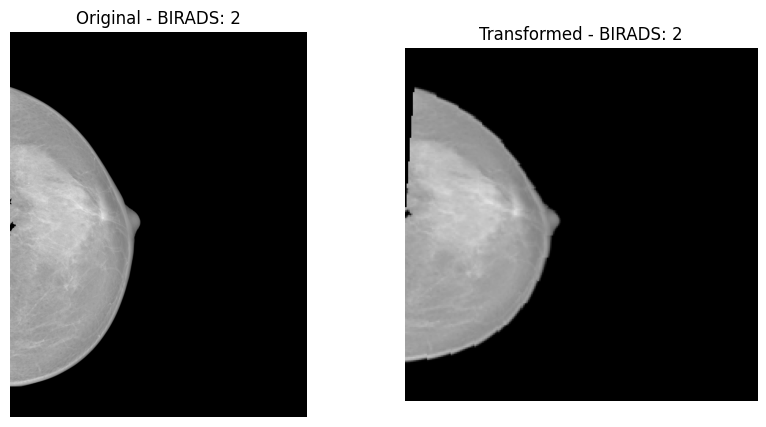

In [14]:
# dataset without transform
dataset_original = MammoBenchDataset(df)

# dataset with transform
dataset_transformed = MammoBenchDataset(df, transform=train_transform)

# get same sample
img_orig, label_orig = dataset_original[231]
img_trans, label_trans = dataset_transformed[231]

# plot side by side
plt.figure(figsize=(10,5))

label_orig = revers_map[label_orig]
label_trans = revers_map[label_trans]
# original
plt.subplot(1,2,1)
plt.imshow(img_orig)
plt.title(f"Original - BIRADS: {label_orig}")
plt.axis("off")

# transformed
plt.subplot(1,2,2)
plt.imshow(unnormalize(img_trans))
plt.title(f"Transformed - BIRADS: {label_trans}")
plt.axis("off")

plt.show()

In [15]:
from sklearn.model_selection import train_test_split


subject_col = 'source_subjectID'
subjects = df['source_subjectID'].unique()
print ("\nTotal Unique Objects :", len(subjects))


train_subjects, temp_subjects = train_test_split(
    subjects,
    test_size=0.30,
    random_state=42
)

val_subjects, test_subjects = train_test_split(
    temp_subjects,
    test_size=0.50,
    random_state=42
)

print("Train subjects:", len(train_subjects))
print("Validation subjects:", len(val_subjects))
print("Test subjects:", len(test_subjects))



train_df = df[df[subject_col].isin(train_subjects)].copy()
val_df = df[df[subject_col].isin(val_subjects)].copy()
test_df = df[df[subject_col].isin(test_subjects)].copy()

print("\nImage counts")
print("Train images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))


Total Unique Objects : 1694
Train subjects: 1185
Validation subjects: 254
Test subjects: 255

Image counts
Train images: 2838
Validation images: 582
Test images: 664


In [16]:
train_set = set(train_df[subject_col].unique())
val_set = set(val_df[subject_col].unique())
test_set = set(test_df[subject_col].unique())

print("\nOverlap check")
print("Train ∩ Val:", len(train_set.intersection(val_set)))
print("Train ∩ Test:", len(train_set.intersection(test_set)))
print("Val ∩ Test:", len(val_set.intersection(test_set)))


print("\nTrain class distribution:")
print(train_df["BIRADS"].value_counts())

print("\nValidation class distribution:")
print(val_df["BIRADS"].value_counts())

print("\nTest class distribution:")
print(test_df["BIRADS"].value_counts())


Overlap check
Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0

Train class distribution:
BIRADS
1.0    1772
3.0     322
2.0     291
4.0     231
5.0     222
Name: count, dtype: int64

Validation class distribution:
BIRADS
1.0    334
4.0     72
2.0     69
3.0     63
5.0     44
Name: count, dtype: int64

Test class distribution:
BIRADS
1.0    447
3.0     70
4.0     55
5.0     47
2.0     45
Name: count, dtype: int64


In [17]:
from torch.utils.data import DataLoader
import torch
train_dataset = MammoBenchDataset(train_df,transform=train_transform)
val_dataset = MammoBenchDataset(val_df,transform=val_test_transform)
test_dataset = MammoBenchDataset(test_df,transform=val_test_transform)


print(" Length of train dataset:", len(train_dataset))
print(" Length of Validation dataset:", len(val_dataset))
print(" Length of test dataset:", len(test_dataset))

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True
)

val_loader = DataLoader(
    val_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False
)

test_loader = DataLoader(
    test_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False
)

print("DataLoaders created successfully.")

images, labels = next(iter(train_loader))

print(images.shape)
print(labels)
print(labels.dtype)
print(labels.min(), labels.max())
print(torch.unique(labels))

 Length of train dataset: 2838
 Length of Validation dataset: 582
 Length of test dataset: 664
DataLoaders created successfully.
torch.Size([32, 3, 224, 224])
tensor([0, 1, 0, 0, 0, 1, 3, 4, 0, 0, 0, 0, 3, 1, 2, 2, 4, 0, 1, 1, 0, 0, 1, 4,
        1, 0, 0, 0, 1, 1, 0, 4])
torch.int64
tensor(0) tensor(4)
tensor([0, 1, 2, 3, 4])


In [18]:
import torch
import torch.nn as nn
from torchvision import models

# Load pretrained Restnet50
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

print(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 211MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [20]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch
import torch.nn as nn

# Get all training labels
train_labels = train_df["birads_label"].values   # change "label" to your actual target column

# Get class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert to tensor and move to device
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class weights:", class_weights)

Class weights: tensor([0.3203, 1.9505, 1.7627, 2.4571, 2.5568], device='cuda:0')


In [23]:
# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer4
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace final classification layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 5)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

print(model.fc)

Using device: cuda
Linear(in_features=2048, out_features=5, bias=True)


In [34]:
from tqdm.notebook import tqdm
num_epochs = 5

train_losses = []
val_losses = []

best_val_loss = float("inf")
patience = 10
patience_counter = 0

best_model_path ="best_restnet50_birads_mammobench.pth"

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    # -------------------------
    # Training phase
    # -------------------------
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    train_bar = tqdm(train_loader, desc="Training", leave=False)

    for images, labels in train_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

        current_loss = running_train_loss / total_train
        current_acc = correct_train / total_train

        train_bar.set_postfix({
            "loss": f"{current_loss:.4f}",
            "acc": f"{current_acc:.4f}"
        })

    train_loss = running_train_loss / total_train
    train_acc = correct_train / total_train

    train_losses.append(train_loss)

    # -------------------------
    # Validation phase
    # -------------------------
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    val_bar = tqdm(val_loader, desc="Validation", leave=False)

    with torch.no_grad():
        for images, labels in val_bar:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)

            current_val_loss = running_val_loss / total_val
            current_val_acc = correct_val / total_val

            val_bar.set_postfix({
                "loss": f"{current_val_loss:.4f}",
                "acc": f"{current_val_acc:.4f}"
            })

    val_loss = running_val_loss / total_val
    val_acc = correct_val / total_val

    val_losses.append(val_loss)

    # -------------------------
    # LR scheduler step
    # -------------------------
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"Learning Rate: {current_lr}")

    # -------------------------
    # Early stopping + save best model
    # -------------------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        torch.save(model.state_dict(), best_model_path)
        print("Best model saved.")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break


Epoch 1/5


Training:   0%|          | 0/89 [00:00<?, ?it/s]

Validation:   0%|          | 0/19 [00:00<?, ?it/s]

Train Loss: 0.9823 | Train Acc: 0.6209
Val Loss:   0.9851 | Val Acc:   0.5636
Learning Rate: 0.0001
Best model saved.

Epoch 2/5


Training:   0%|          | 0/89 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/19 [00:00<?, ?it/s]

Train Loss: 0.8230 | Train Acc: 0.6885
Val Loss:   1.0403 | Val Acc:   0.6014
Learning Rate: 0.0001
No improvement. Patience: 3/10

Epoch 5/5


Training:   0%|          | 0/89 [00:00<?, ?it/s]

Validation:   0%|          | 0/19 [00:00<?, ?it/s]

Train Loss: 0.7894 | Train Acc: 0.6949
Val Loss:   1.0543 | Val Acc:   0.5842
Learning Rate: 0.0001
No improvement. Patience: 4/10


In [41]:
def test_model(model, dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_preds, all_labels

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print (f"Using Device : {device}")
# load best model (IMPORTANT)
model.load_state_dict(torch.load("best_restnet50_birads_mammobench.pth"))

#model.load_state_dict(torch.load("/content/drive/MyDrive/Mammo-Bench/best_restnet50_birads_mammobench.pth", map_location=device))
model.eval()

# run test
y_pred, y_true = test_model(model, test_loader, device)

# metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Test Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Using Device : cuda
Test Accuracy: 0.6099397590361446
Precision: 0.7672516470832493
Recall: 0.6099397590361446
F1 Score: 0.6593828285172979

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.67      0.80       447
           1       0.28      0.62      0.38        45
           2       0.34      0.46      0.39        70
           3       0.19      0.38      0.25        55
           4       0.46      0.55      0.50        47

    accuracy                           0.61       664
   macro avg       0.45      0.54      0.47       664
weighted avg       0.77      0.61      0.66       664



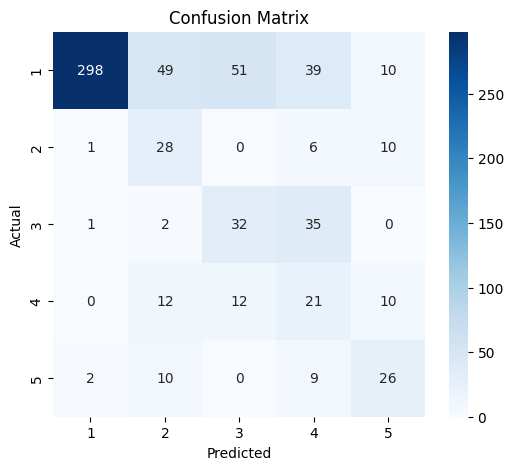

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["1", "2", "3","4","5"],
            yticklabels=["1", "2", "3","4","5"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [44]:
save_path = "/content/drive/MyDrive/Mammo-Bench/best_restnet50_birads_mammobench.pth"

torch.save(model.state_dict(), save_path)

print("Model saved to Drive:", save_path)

Model saved to Drive: /content/drive/MyDrive/Mammo-Bench/best_restnet50_birads_mammobench.pth


In [45]:
model_path = "/content/drive/MyDrive/Mammo-Bench/best_restnet50_birads_mammobench.pth"

model.load_state_dict(torch.load(model_path))
model = model.to(device)
model.eval()

print("Model loaded successfully.")

Model loaded successfully.


In [46]:
import torch
class_names = [1, 2, 3,4,5]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# rebuild model
inference_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
num_features = inference_model.fc.in_features
inference_model.fc = nn.Linear(num_features, 5)

# load trained weights
model_path = "/content/drive/MyDrive/Mammo-Bench/best_restnet50_birads_mammobench.pth"
inference_model.load_state_dict(torch.load(model_path, map_location=device))

inference_model = inference_model.to(device)
inference_model.eval()

def predict_single_image(image_path, model, transform, class_names, device):
    image = Image.open(image_path).convert("RGB")
    image = transform(image)
    image = image.unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(image)
        probabilities = torch.softmax(outputs, dim=1)
        predicted_class_idx = torch.argmax(probabilities, dim=1).item()


    predicted_class = class_names[predicted_class_idx]
    probability_scores = probabilities.cpu().numpy()[0]

    predicted_prob = probability_scores[predicted_class_idx]

    return predicted_class, predicted_prob,probabilities

# test on one image
sample_image_path = df["full_image_path"].iloc[254]

predicted_class, predicted_prob, probabilities = predict_single_image(
    sample_image_path,
    inference_model,
    val_test_transform,
    class_names,
    device
)
P_1 = probabilities[0, 0].item()
P_2 = probabilities[0, 1].item()
P_3 = probabilities[0, 2].item()
P_4 = probabilities[0, 3].item()
P_5 = probabilities[0, 4].item()

print(f"Predicted class: {predicted_class}")
print(f"Confidence: {predicted_prob * 100:.2f}%")




risk_map = {
    1: 0,
    2: 25,
    3: 50,
    4: 75,
    5: 100
}

risk_score = risk_map[predicted_class]

print(f"Predicted BIRADS: {predicted_class}")
print(f"BIRADS Risk Score: {risk_score}")



Using device: cuda
Predicted class: 2
Confidence: 65.20%
Predicted BIRADS: 2
BIRADS Risk Score: 25
